# Figures for the AR-LRX manuscript

Regenerates **Figure 2 - Figure 5** of

> *AR-LRX: Robustness of Adaptive Residual Linear Regression-XGBoost Forecasting
> Across Pharmaceutical and Retail Demand Regimes.*

The notebook reads only the machine-readable result files in `../results/` -
no model is retrained here, so it runs in a few seconds and cannot drift from
the numbers reported in the paper. Every figure is written to `../paper/figures/`
at 400 dpi, sized for a single IJIES column (8.2 cm).

| Figure | Question it answers | Result file |
|---|---|---|
| 2 | How much does the gate weight actually matter? | `exp05b_..._gate_curve.csv` |
| 3 | Are the two demand regimes measurable before the test set is touched? | `exp05b_..._audit.csv`, `exp05d_..._dev.csv`, `exp05c_..._gate.csv` |
| 4 | Does gating prevent degradation where correction is unwarranted? | `exp05c_..._comparison.csv`, `exp05c_..._gate.csv` |
| 5 | Does the validation-fold indicator transfer across regimes? | `exp05b_..._audit.csv`, `exp05c_..._gate.csv` |


## 1. Setup

Colours come from a categorical palette validated for colour-vision deficiency;
every series additionally carries its own line style and marker shape, so the
figures stay readable in greyscale print.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

RESULTS = Path('../results')
FIGDIR = Path('../paper/figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

# design tokens
SURFACE, INK, INK_2 = '#ffffff', '#0b0b0b', '#52514e'
MUTED, GRID, BASELINE = '#898781', '#e1e0d9', '#c3c2b7'
S1C, S2C, S3C = '#2a78d6', '#eb6834', '#1baf7a'   # blue / orange / aqua

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Liberation Serif', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 10,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'axes.edgecolor': BASELINE, 'axes.linewidth': 0.6,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
    'text.color': INK, 'axes.labelcolor': INK_2,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'grid.color': GRID, 'grid.linewidth': 0.5,
})

COL_IN, DPI = 3.23, 400          # 8.2 cm single column
FS = 10                          # IJIES: all lettering in figures is 10 pt


def tidy(ax, xgrid=False):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis='x' if xgrid else 'y', linestyle='-')
    ax.tick_params(length=2.5, pad=2)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(INK_2)


print('matplotlib', plt.matplotlib.__version__)


matplotlib 3.10.9


## 2. Load the result files


In [2]:
curve = pd.read_csv(RESULTS / 'exp05b_rossmann_arlrx_audit_gate_curve.csv')
audit = pd.read_csv(RESULTS / 'exp05b_rossmann_arlrx_audit.csv')
dev   = pd.read_csv(RESULTS / 'exp05d_rossmann_arlrx_dev.csv')
gate  = pd.read_csv(RESULTS / 'exp05c_pharma_arlrx_gate.csv')
comp  = pd.read_csv(RESULTS / 'exp05c_pharma_arlrx_comparison.csv')

V3 = 'V3_sales_lagged'

# the nine retail AR-LRX configurations of exp05b, indexed by (feature set, first stage)
arlrx = audit[audit.model.str.startswith('AR-LRX')].copy()
arlrx_ix = arlrx.set_index(['feature_set', 'stage1'])

# realised test improvement over the first stage alone
arlrx['test_gain'] = ((arlrx.stage1_only_test_RMSE - arlrx.test_RMSE)
                      / arlrx.stage1_only_test_RMSE * 100)

pharma = gate[gate.model == 'AR-LRX [linear]'].copy()
pharma['test_gain'] = ((pharma.stage1_only_test_RMSE - pharma.test_RMSE)
                       / pharma.stage1_only_test_RMSE * 100)

print(f'retail gate curve   : {len(curve):4d} rows')
print(f'retail AR-LRX runs  : {len(arlrx):4d} rows (exp05b) + {len(dev):3d} rows (exp05d)')
print(f'pharmaceutical runs : {len(pharma):4d} configurations')


retail gate curve   :  189 rows
retail AR-LRX runs  :    9 rows (exp05b) +  18 rows (exp05d)
pharmaceutical runs :   32 configurations


## 3. Figure 2 - how much does the gate weight matter?

Test RMSE on the retail `V3` panel as a continuous function of the gate weight *w*.
With a **linear** first stage the curve falls steeply across the whole range, so any
shrinkage is costly. With a **structural** first stage it is nearly flat above
*w* = 0.6 - the weight barely matters, which is why the gate contributes almost no
accuracy in this regime.

Filled markers give the weight selected on the validation fold; open markers give the
weight that minimises test error. The gap between them is the price of selecting from
validation, and the open markers are a **post-hoc diagnostic only** - they never enter
model selection.


linear         w*=0.80 ->  1140.80   best w=1.00 ->  1061.50   price +7.471%
structural     w*=0.70 ->  1016.14   best w=0.85 ->  1005.43   price +1.065%
struct_linear  w*=0.80 ->   998.15   best w=0.90 ->   994.18   price +0.399%


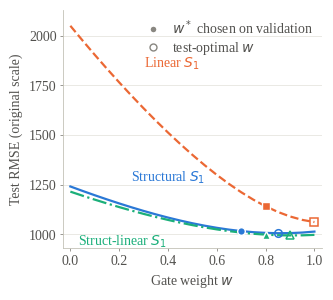

In [3]:
fig, ax = plt.subplots(figsize=(COL_IN, 2.90))

series = [('linear',        'Linear $S_1$',        S2C, '--', 's'),
          ('structural',    'Structural $S_1$',    S1C, '-',  'o'),
          ('struct_linear', 'Struct-linear $S_1$', S3C, '-.', '^')]

for kind, label, col, ls, mk in series:
    g = curve[(curve.varian == V3) & (curve.S1 == kind)].sort_values('w')
    ax.plot(g.w, g['RMSE asli'], color=col, lw=1.6, ls=ls, zorder=3, label=label)

    w_star = float(arlrx_ix.loc[(V3, kind), 'gate_w'])
    y_star = float(g.loc[np.isclose(g.w, w_star), 'RMSE asli'].iloc[0])
    ax.plot([w_star], [y_star], marker=mk, ms=5.5, color=col,
            mec=SURFACE, mew=1.0, ls='none', zorder=5)

    w_best = float(g.loc[g['RMSE asli'].idxmin(), 'w'])
    ax.plot([w_best], [g['RMSE asli'].min()], marker=mk, ms=5.5, mfc='none',
            mec=col, mew=1.1, ls='none', zorder=4)
    print(f'{kind:14s} w*={w_star:.2f} -> {y_star:8.2f}   '
          f'best w={w_best:.2f} -> {g["RMSE asli"].min():8.2f}   '
          f'price {(y_star - g["RMSE asli"].min()) / g["RMSE asli"].min() * 100:+.3f}%')

ax.set_xlabel('Gate weight $w$')
ax.set_ylabel('Test RMSE (original scale)')
ax.set_xlim(-0.03, 1.03)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_ylim(930, 2130)
ax.set_yticks([1000, 1250, 1500, 1750, 2000])
tidy(ax)

ax.annotate('Linear $S_1$', xy=(0.30, 1840), color=S2C, fontsize=FS)
ax.annotate('Struct-linear $S_1$', xy=(0.03, 945), color=S3C, fontsize=FS)
ax.annotate('Structural $S_1$', xy=(0.25, 1265), color=S1C, fontsize=FS)

ax.legend(handles=[Line2D([], [], marker='o', ms=5, ls='none', color=MUTED,
                          mec=SURFACE, label='$w^*$ chosen on validation'),
                   Line2D([], [], marker='o', ms=5, ls='none', mfc='none',
                          mec=MUTED, label='test-optimal $w$')],
          loc='upper right', frameon=False, handletextpad=0.4,
          borderpad=0.1, labelspacing=0.25, labelcolor=INK_2)

fig.tight_layout(pad=0.35)
fig.savefig(FIGDIR / 'fig2_gate_curve.png', dpi=DPI)
plt.show()


## 4. Figure 3 - the regime diagnostic

`resid_val_r2` is the coefficient of determination of the **second** stage on the
**validation** residuals. It is computable before any test observation is used, and it
is what separates the two demand regimes.

Reported honestly: the separation is not perfect. The retail configurations of the
`V1` feature set - the one from which the informative predictor was removed - sit
marginally below zero, alongside the pharmaceutical series.


retail        : n= 27  min -0.0278  max +0.5872  positive 19
pharmaceutical: n= 32  min -2.4466  max +0.0145  median -0.1069  negative 31


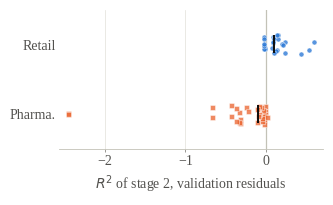

In [4]:
retail_r2 = pd.concat([arlrx.resid_val_r2, dev.resid_val_r2]).to_numpy()
pharma_r2 = pharma.resid_val_r2.to_numpy()

print(f'retail        : n={retail_r2.size:3d}  '
      f'min {retail_r2.min():+.4f}  max {retail_r2.max():+.4f}  '
      f'positive {int((retail_r2 > 0).sum())}')
print(f'pharmaceutical: n={pharma_r2.size:3d}  '
      f'min {pharma_r2.min():+.4f}  max {pharma_r2.max():+.4f}  '
      f'median {np.median(pharma_r2):+.4f}  '
      f'negative {int((pharma_r2 < 0).sum())}')

fig, ax = plt.subplots(figsize=(COL_IN, 1.95))
rng = np.random.default_rng(7)

for i, (vals, col, mk) in enumerate([(retail_r2, S1C, 'o'), (pharma_r2, S2C, 's')]):
    y = 1 - i
    ax.plot(vals, y + rng.uniform(-0.14, 0.14, vals.size), marker=mk, ms=3.6,
            ls='none', color=col, alpha=0.78, mec=SURFACE, mew=0.4, zorder=3)
    ax.plot([np.median(vals)], [y], marker='|', ms=13, color=INK, mew=1.4, zorder=5)

ax.axvline(0, color=BASELINE, lw=0.9, zorder=1)
ax.set_yticks([1, 0])
ax.set_yticklabels(['Retail', 'Pharma.'], fontsize=FS)
ax.set_ylim(-0.5, 1.5)
lo = min(retail_r2.min(), pharma_r2.min())
hi = max(retail_r2.max(), pharma_r2.max())
ax.set_xlim(lo - 0.12, hi + 0.12)
assert ax.get_xlim()[0] < lo and ax.get_xlim()[1] > hi   # no point outside the axes
ax.set_xlabel('$R^2$ of stage 2, validation residuals')
tidy(ax, xgrid=True)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

fig.tight_layout(pad=0.35)
fig.savefig(FIGDIR / 'fig3_regime.png', dpi=DPI)
plt.show()


## 5. Figure 4 - what the gate buys

Change in test RMSE relative to the first stage **alone**, over the 32 pharmaceutical
configurations. Positive means the residual correction made the forecast worse.

This is the robustness claim of the paper in one picture: gating does not shift the
whole distribution, it removes the ungated framework's long right tail.


Ungated hybrid     worse than $S_1$ in 19 of 32  mean +1.766%  worst +11.382%
AR-LRX, gated      worse than $S_1$ in  8 of 32  mean +0.219%  worst +4.482%
AR-LRX, augmented  worse than $S_1$ in  5 of 32  mean +0.309%  worst +14.478%


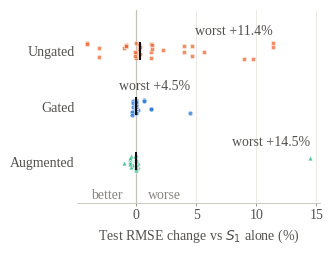

In [5]:
ungated = ((comp['LR-XGB (residual, tanpa gerbang)'] - comp['S1 [linear]'])
           / comp['S1 [linear]'] * 100).to_numpy()


def deviation(model_name):
    s = gate[gate.model == model_name]
    return ((s.test_RMSE - s.stage1_only_test_RMSE)
            / s.stage1_only_test_RMSE * 100).to_numpy()


groups = [('Ungated hybrid',    ungated,                        S2C, 's'),
          ('AR-LRX, gated',     deviation('AR-LRX [linear]'),   S1C, 'o'),
          ('AR-LRX, augmented', deviation('AR-LRX-Aug [linear]'), S3C, '^')]

for name, vals, _, _ in groups:
    print(f'{name:18s} worse than $S_1$ in {int((vals > 1e-9).sum()):2d} of {vals.size}  '
          f'mean {vals.mean():+.3f}%  worst {vals.max():+.3f}%')

fig, ax = plt.subplots(figsize=(COL_IN, 2.45))
rng = np.random.default_rng(42)

for i, (label, vals, col, mk) in enumerate(groups):
    y = len(groups) - 1 - i
    ax.plot(vals, y + rng.uniform(-0.16, 0.16, vals.size), marker=mk, ms=3.4,
            ls='none', color=col, alpha=0.75, mec=SURFACE, mew=0.4, zorder=3)
    ax.plot([np.median(vals)], [y], marker='|', ms=13, color=INK, mew=1.4, zorder=5)
    ax.annotate(f'worst {vals.max():+.1f}%', xy=(vals.max(), y + 0.24),
                fontsize=FS, color=INK_2, ha='right', va='bottom')

ax.axvline(0, color=BASELINE, lw=0.9, zorder=1)
ax.set_yticks(range(len(groups)))
ax.set_yticklabels(['Ungated', 'Gated', 'Augmented'][::-1], fontsize=FS)
ax.set_ylim(-0.75, len(groups) - 0.25)
allv = np.concatenate([g[1] for g in groups])
ax.set_xlim(min(-4.6, allv.min() - 0.8), allv.max() + 0.8)
assert ax.get_xlim()[0] < allv.min() and ax.get_xlim()[1] > allv.max()
ax.set_xlabel('Test RMSE change vs $S_1$ alone (%)')
tidy(ax, xgrid=True)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.annotate('better', xy=(-2.4, -0.68), fontsize=FS, color=MUTED, ha='center')
ax.annotate('worse',  xy=(2.4, -0.68),  fontsize=FS, color=MUTED, ha='center')

fig.tight_layout(pad=0.35)
fig.savefig(FIGDIR / 'fig4_degradation.png', dpi=DPI)
plt.show()


## 6. Figure 5 - a diagnostic that does not generalise

The improvement the gate produces **on the validation fold**, against the improvement
actually realised **on the test fold**. On the retail panel the indicator is reliable;
on the pharmaceutical series the relationship reverses, so it must not be used on its
own as a decision rule. Reporting this is the point - it is a negative result about our
own diagnostic.


retail         r = +0.9646  (n=9)
pharmaceutical r = -0.9037  (n=32)

of the 15 pharmaceutical configurations where the gate opened,
  validation promised +0.502% on average
  the test fold delivered -0.466%
  and only 7 improved at all


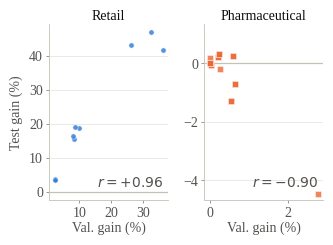

In [6]:
r_retail = np.corrcoef(arlrx.gate_val_gain_pct, arlrx.test_gain)[0, 1]
r_pharma = np.corrcoef(pharma.gate_val_gain_pct, pharma.test_gain)[0, 1]
print(f'retail         r = {r_retail:+.4f}  (n={len(arlrx)})')
print(f'pharmaceutical r = {r_pharma:+.4f}  (n={len(pharma)})')

open_gate = pharma[pharma.gate_w > 0]
print(f'\nof the {len(open_gate)} pharmaceutical configurations where the gate opened,')
print(f'  validation promised {open_gate.gate_val_gain_pct.mean():+.3f}% on average')
print(f'  the test fold delivered {open_gate.test_gain.mean():+.3f}%')
print(f'  and only {int((open_gate.test_gain > 0).sum())} improved at all')

fig, axes = plt.subplots(1, 2, figsize=(COL_IN, 2.35))

panels = [(axes[0], arlrx.gate_val_gain_pct, arlrx.test_gain, S1C, 'o',
           'Retail', r_retail),
          (axes[1], pharma.gate_val_gain_pct, pharma.test_gain, S2C, 's',
           'Pharmaceutical', r_pharma)]

for ax, x, y, col, mk, title, r in panels:
    ax.axhline(0, color=BASELINE, lw=0.9, zorder=1)
    ax.plot(x, y, marker=mk, ms=3.8, ls='none', color=col, alpha=0.8,
            mec=SURFACE, mew=0.4, zorder=3)
    ax.set_title(title, fontsize=FS, color=INK, pad=3)
    ax.annotate(f'$r = {r:+.2f}$', xy=(0.96, 0.06), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=FS, color=INK_2)
    ax.set_xlabel('Val. gain (%)', labelpad=1.5)
    tidy(ax)

axes[0].set_ylabel('Test gain (%)')
py = pharma.test_gain
axes[1].set_ylim(min(-1.35, py.min() - 0.2), max(1.35, py.max() + 0.2))

fig.tight_layout(pad=0.35, w_pad=1.1)
fig.savefig(FIGDIR / 'fig5_diagnostic.png', dpi=DPI)
plt.show()


## 7. Check what was written


In [7]:
for p in sorted(FIGDIR.glob('fig*.png')):
    print(f'{p.name:24s} {p.stat().st_size / 1024:7.1f} kB')


fig1_framework.png         266.0 kB
fig2_gate_curve.png        134.1 kB
fig3_regime.png             44.1 kB
fig4_degradation.png        89.5 kB
fig5_diagnostic.png         68.2 kB
